# Pipe Length Sensitivity Study

## Objective

Study how pipe length affects:

- Pressure
- Flow
- Velocity
- Headloss

using EPANET hydraulic simulations.

---

## Theory

The Hazen-Williams equation is

hf = (10.67 × L × Q^1.852) /
     (C^1.852 × D^4.87)

where

hf = Headloss

L = Pipe Length

Q = Flow

D = Pipe Diameter

C = Roughness

Expected Behaviour

Length ↑

↓

Headloss ↑

↓

Pressure ↓

↓

Flow ≈ Constant

↓

Velocity ≈ Constant

In [113]:
import wntr
import copy
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
wn = wntr.network.WaterNetworkModel("production_benchmark.inp")

print("Baseline Network Created")

Baseline Network Created


C:\Users\Jatin\AppData\Local\Temp\ipykernel_3828\3710083180.py:3: DeprecationWarning: wntr.network.WaterNetworkModel.get_graph is deprecated, use wntr.network.WaterNetworkModel.to_graph instead
  G = wn.get_graph()


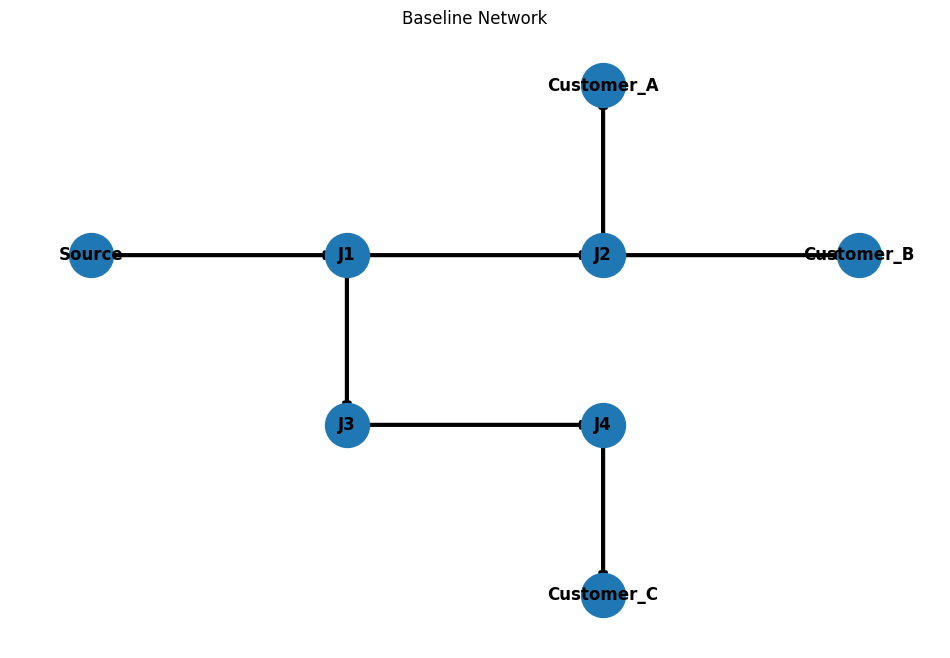

In [115]:
import networkx as nx

G = wn.get_graph()

pos = {}

for node_name in wn.node_name_list:
    node = wn.get_node(node_name)
    pos[node_name] = node.coordinates

plt.figure(figsize=(12,8))

nx.draw_networkx_nodes(G,pos,node_size=1000)
nx.draw_networkx_edges(G,pos,width=3)
nx.draw_networkx_labels(G,pos,font_weight="bold")
plt.title("Baseline Network")

plt.axis("off")
plt.show()


In [116]:
pipes = [

    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7"

]

lengths = [

    500,
    750,
    1000,
    1250,
    1500,
    1750,
    2000

]

In [117]:
benchmark =[]
for changed_pipe in pipes :
    print(f"Running {changed_pipe}")

    for L in lengths:
        wn_test = copy.deepcopy(wn)
        wn_test.get_link(changed_pipe).length = L

        sim = wntr.sim.EpanetSimulator(wn_test)
        result = sim.run_sim()

        pressure= result.node["pressure"].iloc[-1]
        flow = result.link["flowrate"].iloc[-1]
        velocity = result.link["velocity"].iloc[-1]
        headloss = result.link["headloss"].iloc[-1]
        if changed_pipe == "P2":
                print(
                    L,
                    wn_test.get_link("P2").length
                )

        row = {"Changed_Pipe" : changed_pipe, "Length": L}

        for node in pressure.index:
            row[f"Pressure_{node}"] = pressure[node]

        for pipe in flow.index:
            row[f"Flow_{pipe}"] = flow[pipe]

        for pipe in velocity.index:
            row[f"Velocity_{pipe}"] = velocity[pipe]

        for pipe in headloss.index:
            row[f"Headloss_{pipe}"] = headloss[pipe]

        benchmark.append(row)

benchmark_df = pd.DataFrame(benchmark)

benchmark_df.head()

print(
    changed_pipe,
    wn_test.get_link(changed_pipe).length
)

Running P1
Running P2
500 500.0
750 750.0
1000 1000.0
1250 1250.0
1500 1500.0
1750 1750.0
2000 2000.0
Running P3
Running P4
Running P5
Running P6
Running P7
P7 2000.0


In [118]:
for L in lengths:

    wn_test = copy.deepcopy(wn)

    wn_test.get_link("P2").length = L

    sim = wntr.sim.EpanetSimulator(wn_test)

    result = sim.run_sim()

    gradient = result.link["headloss"].iloc[-1]["P2"]

    total = gradient * L

    print(
        f"Length={L:4d} m | Gradient={gradient:.6f} | Total={total:.3f}"
    )


print(result.link["headloss"].attrs)  
print(result.link["headloss"])

Length= 500 m | Gradient=0.003530 | Total=1.765
Length= 750 m | Gradient=0.003530 | Total=2.647
Length=1000 m | Gradient=0.003530 | Total=3.530
Length=1250 m | Gradient=0.003530 | Total=4.412
Length=1500 m | Gradient=0.003530 | Total=5.295
Length=1750 m | Gradient=0.003530 | Total=6.177
Length=2000 m | Gradient=0.003530 | Total=7.059
{}
         P1       P2        P3        P4       P5        P6        P7
0  0.007479  0.00353  0.004844  0.016474  0.00967  0.007322  0.016474


### Observation

The EPANET/WNTR `headloss` output remained constant while pipe length increased.

Further investigation showed that the reported value behaves as a **headloss gradient (m/m)** rather than the total headloss across the pipe.

The total headloss was calculated as:

Total Headloss = Headloss Gradient × Pipe Length

The resulting values increased linearly with pipe length, confirming the Hazen–Williams equation:

hf ∝ L

This validates the hydraulic solver's implementation.

In [119]:
benchmark_df.to_csv(

    "length_sensitivity_benchmark.csv",

    index=False

)

In [120]:
p2 = benchmark_df[

    benchmark_df["Changed_Pipe"]=="P2"

]

p2

,Changed_Pipe,Length,Pressure_J1,Pressure_J2,Pressure_J3,Pressure_J4,Pressure_Customer_A,Pressure_Customer_B,Pressure_Customer_C,Pressure_Source,...,Velocity_P5,Velocity_P6,Velocity_P7,Headloss_P1,Headloss_P2,Headloss_P3,Headloss_P4,Headloss_P5,Headloss_P6,Headloss_P7
7,P2,500,102.520699,98.755844,93.645836,74.171478,85.920891,84.362503,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
8,P2,750,102.520699,97.873413,93.645836,74.171478,85.038460,83.480072,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
9,P2,1000,102.520699,96.990982,93.645836,74.171478,84.156029,82.597641,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
10,P2,1250,102.520699,96.108543,93.645836,74.171478,83.273605,81.715210,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
11,P2,1500,102.520699,95.226128,93.645836,74.171478,82.391167,80.832779,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
12,P2,1750,102.520699,94.343689,93.645836,74.171478,81.508743,79.950363,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474
13,P2,2000,102.520699,93.461258,93.645836,74.171478,80.626312,79.067924,55.639431,-0.000004,...,1.510352,1.522782,2.013802,0.007479,0.00353,0.004844,0.016474,0.00967,0.007322,0.016474


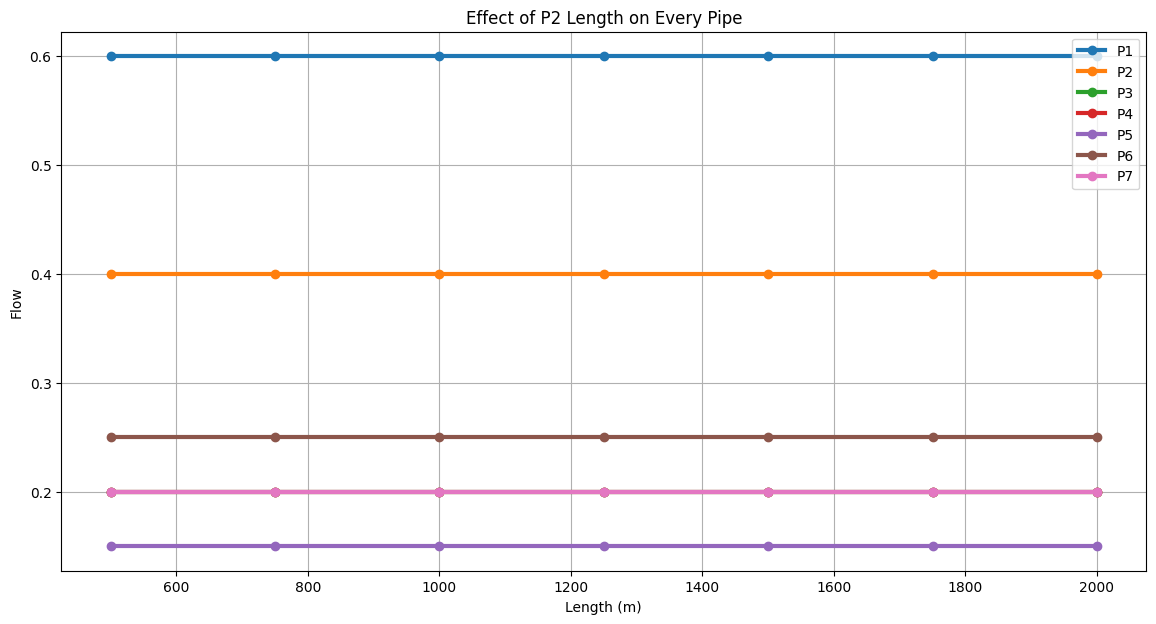

In [121]:
plt.figure(figsize=(14,7))

for pipe in pipes:

    plt.plot(

        p2["Length"],

        p2[f"Flow_{pipe}"],

        marker="o",

        linewidth=3,

        label=pipe

    )

plt.title(

    "Effect of P2 Length on Every Pipe"

)

plt.xlabel(

    "Length (m)"

)

plt.ylabel(

    "Flow"

)

plt.grid(True)

plt.legend()

plt.show()

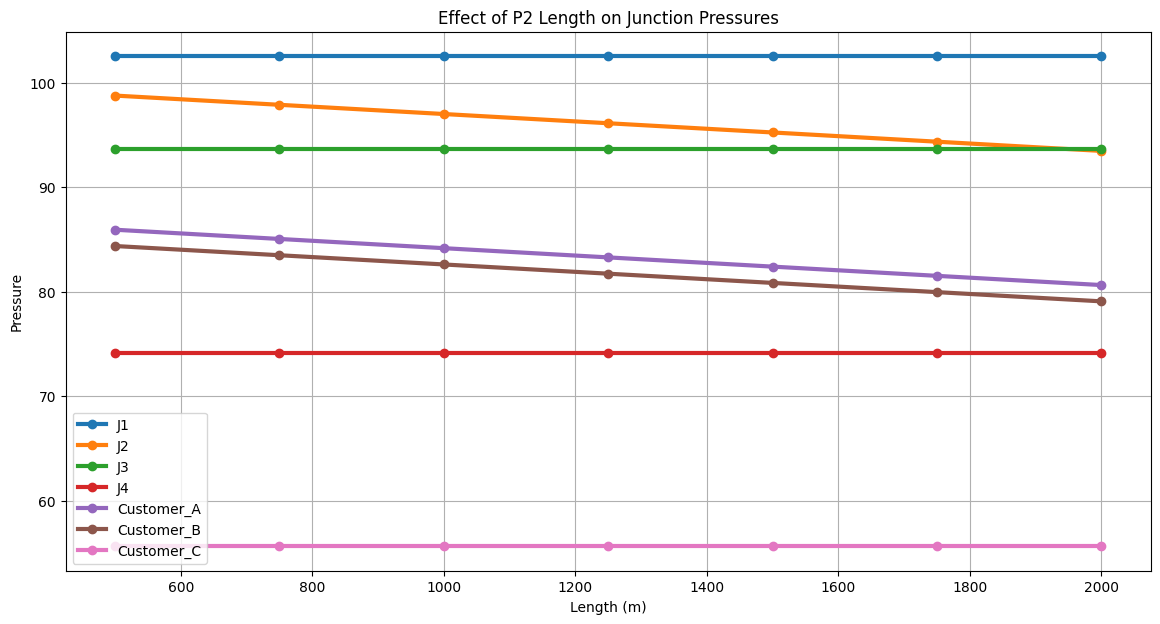

In [122]:
pressure_nodes = [

    "Pressure_J1",
    "Pressure_J2",
    "Pressure_J3",
    "Pressure_J4",
    "Pressure_Customer_A",
    "Pressure_Customer_B",
    "Pressure_Customer_C"

]

plt.figure(figsize=(14,7))

for node in pressure_nodes:

    plt.plot(

        p2["Length"],

        p2[node],

        marker="o",

        linewidth=3,

        label=node.replace(
            "Pressure_",
            ""
        )

    )

plt.title(

    "Effect of P2 Length on Junction Pressures"

)

plt.xlabel(

    "Length (m)"

)

plt.ylabel(

    "Pressure"

)

plt.grid(True)

plt.legend()

plt.show()

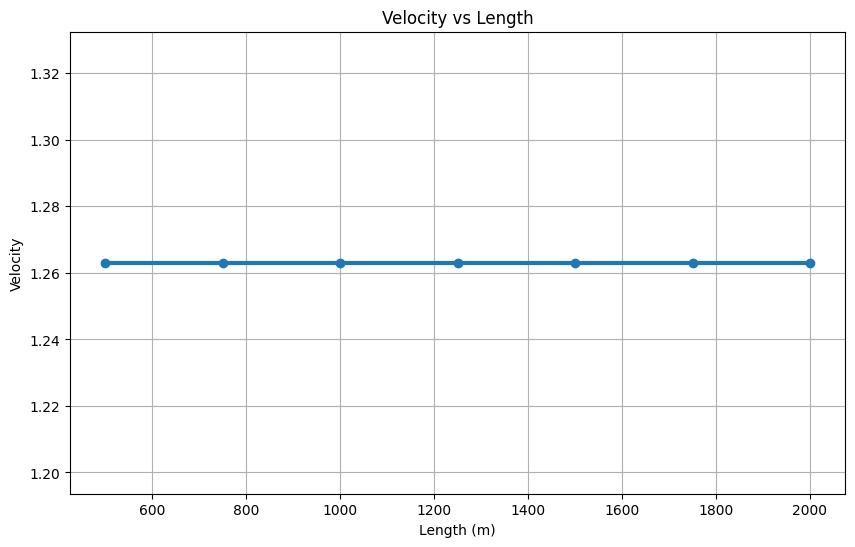

In [127]:
changed_pipe = "P5"

pipe_data = benchmark_df[
    benchmark_df["Changed_Pipe"] == changed_pipe
]

plt.figure(figsize=(10,6))

plt.plot(

    p2["Length"],

    p2["Velocity_P2"],

    marker="o",

    linewidth=3

)

plt.grid(True)

plt.title(

    "Velocity vs Length"

)

plt.xlabel(

    "Length (m)"

)

plt.ylabel(

    "Velocity"

)

plt.show()

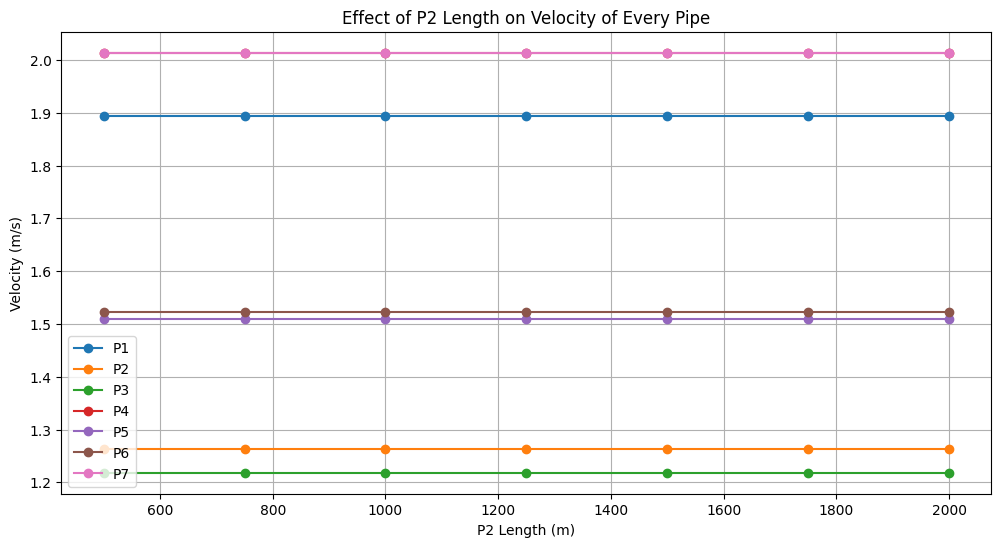

In [128]:
plt.figure(figsize=(12,6))

for pipe in pipes:
    plt.plot(
        p2["Length"],
        p2[f"Velocity_{pipe}"],
        marker="o",
        label=pipe
    )

plt.title("Effect of P2 Length on Velocity of Every Pipe")
plt.xlabel("P2 Length (m)")
plt.ylabel("Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.show()

C:\Users\Jatin\AppData\Local\Temp\ipykernel_3828\2811356117.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p2["Total_Headloss"] = (


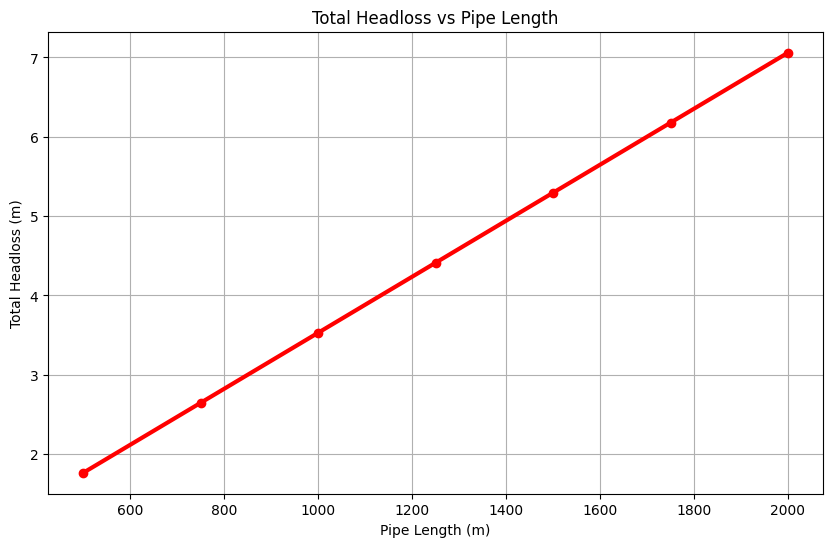

In [124]:
p2["Total_Headloss"] = (
    p2["Headloss_P2"] *
    p2["Length"]
)


plt.figure(figsize=(10,6))

plt.plot(
    p2["Length"],
    p2["Total_Headloss"],
    marker="o",
    linewidth=3,
    color="red"
)

plt.grid(True)

plt.title("Total Headloss vs Pipe Length")

plt.xlabel("Pipe Length (m)")

plt.ylabel("Total Headloss (m)")

plt.show()

### Observation

The EPANET/WNTR `headloss` output remained constant while pipe length increased.

Further investigation showed that the reported value behaves as a **headloss gradient (m/m)** rather than the total headloss across the pipe.

The total headloss was calculated as:

Total Headloss = Headloss Gradient × Pipe Length

The resulting values increased linearly with pipe length, confirming the Hazen–Williams equation:

hf ∝ L

This validates the hydraulic solver's implementation.

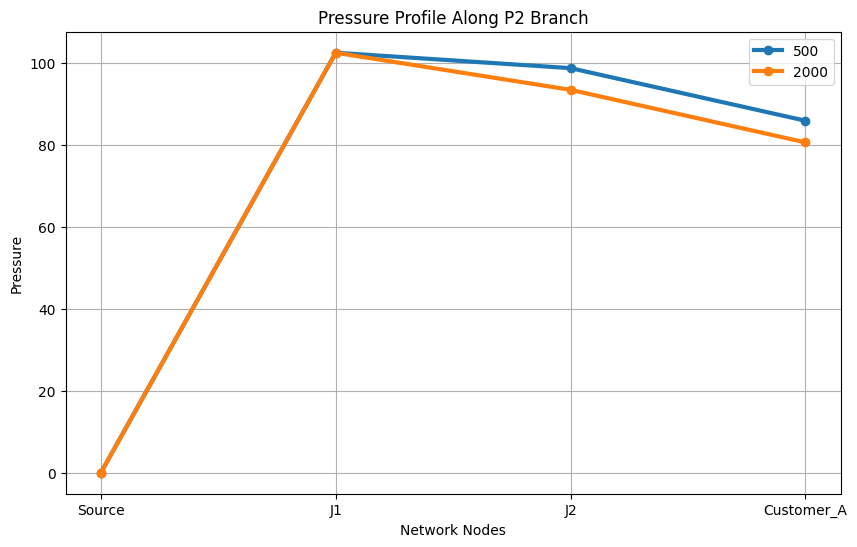

In [125]:
baseline = benchmark_df[
    (benchmark_df["Changed_Pipe"]=="P2") &
    (benchmark_df["Length"]==500)
].iloc[0]

small = benchmark_df[
    (benchmark_df["Changed_Pipe"]=="P2") &
    (benchmark_df["Length"]==2000)
].iloc[0]

nodes = [
    "Source",
    "J1",
    "J2",
    "Customer_A"
]

baseline_pressure = [
    baseline["Pressure_Source"],
    baseline["Pressure_J1"],
    baseline["Pressure_J2"],
    baseline["Pressure_Customer_A"]
]

small_pressure = [
    small["Pressure_Source"],
    small["Pressure_J1"],
    small["Pressure_J2"],
    small["Pressure_Customer_A"]
]

plt.figure(figsize=(10,6))

plt.plot(
    nodes,
    baseline_pressure,
    marker="o",
    linewidth=3,
    label="500"
)

plt.plot(
    nodes,
    small_pressure,
    marker="o",
    linewidth=3,
    label="2000"
)

plt.title("Pressure Profile Along P2 Branch")

plt.xlabel("Network Nodes")

plt.ylabel("Pressure")

plt.grid(True)

plt.legend()

plt.show()